# CNN Classification on Original and Transformed MNIST

## Image Processing and CNN

This notebook implements and evaluates a simple Convolutional Neural Network (CNN) for the MNIST handwritten digit classification problem.

The model is first trained using the regular MNIST training dataset.

The trained model is then evaluated on:

1. Original MNIST test data
2. Colored MNIST test data
3. Rotated MNIST test data

The transformed datasets are created from the MNIST test dataset.

The requirements demonstrated in this notebook are:

- Training loss curve
- Testing accuracy on original MNIST
- Testing accuracy on transformed MNIST
- Color-wise performance analysis
- Rotation-angle-wise performance analysis

I included an optional model-improvement experiment at the end.

## Import Required Libraries

The required Python, PyTorch, Torchvision, NumPy, Pandas and Matplotlib libraries are imported below.

A random seed is also specified to improve reproducibility of the experiment.

In [ ]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
from torchvision.transforms import functional as TF

# For Reproducibility purpose
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# I selected one of my GPUs due to its available [I am using Colab Pro+]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device being used:", device)

Device being used: cuda



## I am using Regular MNIST, So, I need to load the Regular MNIST Dataset

The CNN will be trained using only the regular MNIST training dataset.

MNIST images are originally grayscale with one channel.

Because Colored MNIST will later contain three RGB channels, the regular grayscale MNIST images are replicated across three channels.

Therefore, the same CNN architecture can process both regular and colored MNIST images.

In [ ]:
# Let me first do transformation for regular MNIST

regular_transform = transforms.Compose([
    transforms.ToTensor(),

    # Then convert grayscale image from 1 channel to 3 identical channels
    transforms.Lambda(lambda x: x.repeat(3, 1, 1)),

    # Then normalize all three channels using MNIST mean and standard deviation
    transforms.Normalize(
        (0.1307, 0.1307, 0.1307),
        (0.3081, 0.3081, 0.3081)
    )
])

# Training dataset
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=regular_transform
)

# Test dataset
test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=regular_transform
)

print("My number of training images:", len(train_dataset))
print("My number of testing images:", len(test_dataset))

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.38MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 129kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.25MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.58MB/s]

My number of training images: 60000
My number of testing images: 10000


## I want to create DataLoaders

DataLoaders are used to divide the MNIST datasets into smaller batches during training and testing.

In [ ]:
BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("My number of training batches:", len(train_loader))
print("My number of testing batches:", len(test_loader))

My number of training batches: 469
My number of testing batches: 79


## Let me visualize samples from the Regular MNIST Dataset

The following cell displays several examples from the regular MNIST training dataset before training the CNN.

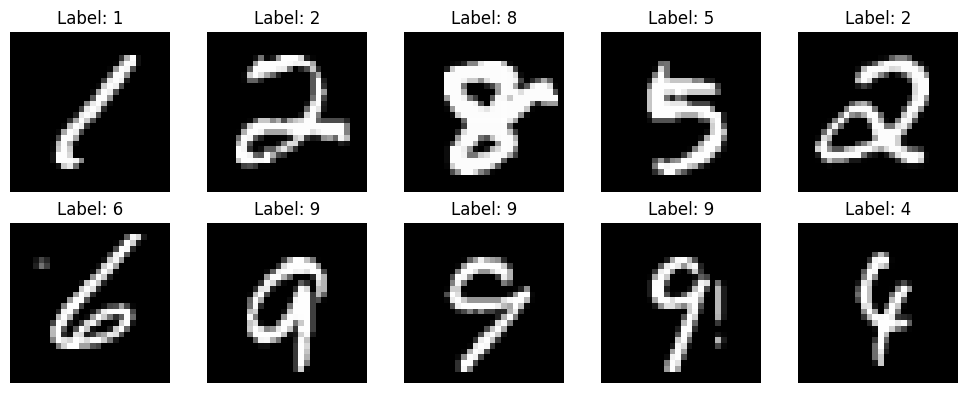

In [ ]:
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.flat):

    # I need to reverse normalization for visualization
    image = images[i] * 0.3081 + 0.1307

    image = image.clamp(0, 1)

    ax.imshow(image.permute(1, 2, 0).cpu())

    ax.set_title(f"Label: {labels[i].item()}")

    ax.axis("off")

plt.tight_layout()
plt.show()

## I need to define the CNN Model

A simple Convolutional Neural Network is used for classification.

The network consists of:

- Two convolutional layers
- ReLU activation functions
- Two max-pooling operations
- One dropout layer
- Two fully connected layers

The final output layer contains 10 neurons corresponding to the digits 0 to 9.

In [ ]:
class SimpleCNN(nn.Module):

    def __init__(self):

        super(SimpleCNN, self).__init__()

        # First convolutional layer
        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        # Second convolutional layer
        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=1
        )

        # Max pooling
        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        # Dropout
        self.dropout = nn.Dropout(0.25)

        # Fully connected layers
        self.fc1 = nn.Linear(
            64 * 7 * 7,
            128
        )

        self.fc2 = nn.Linear(
            128,
            10
        )

    def forward(self, x):

        x = F.relu(self.conv1(x))

        x = self.pool(x)

        x = F.relu(self.conv2(x))

        x = self.pool(x)

        x = torch.flatten(x, 1)

        x = self.dropout(x)

        x = F.relu(self.fc1(x))

        x = self.fc2(x)

        return x


model = SimpleCNN().to(device)

print(model)

SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


## Let me now train the CNN Using Regular MNIST

The baseline CNN is trained only on the original regular MNIST training dataset.

The colored and rotated datasets will not be used to train this baseline model.

This allows us to evaluate how well a CNN trained on normal MNIST generalizes to transformed images.

In [ ]:
# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

# My number of training epochs
EPOCHS = 5

# I am storing training loss after each epoch
training_losses = []

In [ ]:
for epoch in range(EPOCHS):

    model.train()

    running_loss = 0.0

    total_samples = 0

    for images, labels in train_loader:

        images = images.to(device)

        labels = labels.to(device)

        # Reset gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update parameters
        optimizer.step()

        batch_size = labels.size(0)

        running_loss += loss.item() * batch_size

        total_samples += batch_size

    average_loss = running_loss / total_samples

    training_losses.append(average_loss)

    print(
        f"Epoch {epoch + 1}/{EPOCHS}, "
        f"My training Loss: {average_loss:.4f}"
    )

Epoch 1/5, My training Loss: 0.1713
Epoch 2/5, My training Loss: 0.0523
Epoch 3/5, My training Loss: 0.0383
Epoch 4/5, My training Loss: 0.0295
Epoch 5/5, My training Loss: 0.0235


# a. TRAINING LOSS CURVE

The training loss is plotted against the training epochs.

A decreasing loss generally indicates that the CNN is learning from the MNIST training dataset.

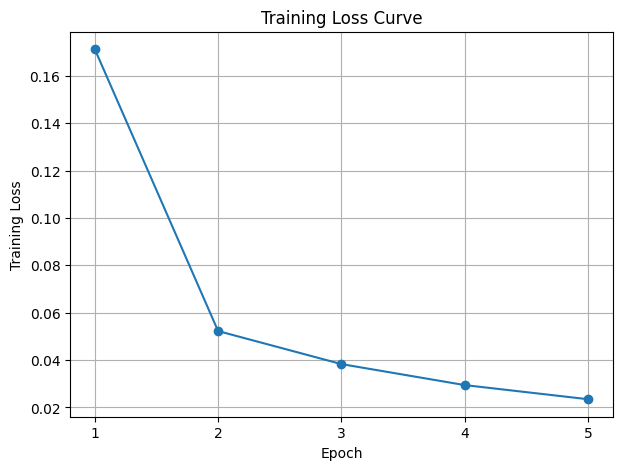

In [ ]:
plt.figure(figsize=(7, 5))

plt.plot(
    range(1, EPOCHS + 1),
    training_losses,
    marker="o"
)

plt.xlabel("Epoch")

plt.ylabel("Training Loss")

plt.title("Training Loss Curve")

plt.xticks(range(1, EPOCHS + 1))

plt.grid(True)

plt.show()

## I need to define the Evaluation Function

The following function calculates classification loss and accuracy for a given dataset.

The same evaluation procedure will be used for the original, colored, and rotated MNIST test datasets.

In [ ]:
@torch.no_grad()
def evaluate_model(model, data_loader):

    model.eval()

    correct = 0

    total = 0

    total_loss = 0.0

    for images, labels in data_loader:

        images = images.to(device)

        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

        total_loss += (
            loss.item() * labels.size(0)
        )

    average_loss = total_loss / total

    accuracy = 100 * correct / total

    return average_loss, accuracy

## b. TESTING ACCURACY ON THE ORIGINAL DATASET

The trained CNN is first evaluated using the original MNIST test dataset.

This provides my baseline performance before applying any image transformation.

In [ ]:
original_loss, original_accuracy = evaluate_model(
    model,
    test_loader
)

print(
    f"My original MNIST Test Loss: "
    f"{original_loss:.4f}"
)

print(
    f"My original MNIST Test Accuracy: "
    f"{original_accuracy:.2f}%"
)

My original MNIST Test Loss: 0.0244
My original MNIST Test Accuracy: 99.18%


# Transformation 1: Colored MNIST

## Let's create colored MNIST

The first transformed dataset is Colored MNIST.

The original grayscale digit intensity is used as a mask and the digit is assigned one of three RGB colors:

- Red
- Green
- Blue

The background remains black.

Three colors are used in order to satisfy the requirement of adding at least three colors to MNIST.

In [ ]:
# Load raw MNIST test images without normalization

raw_test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True
)

COLOR_NAMES = [
    "Red",
    "Green",
    "Blue"
]

COLOR_VECTORS = {

    "Red":
    torch.tensor(
        [1.0, 0.0, 0.0]
    ).view(3, 1, 1),

    "Green":
    torch.tensor(
        [0.0, 1.0, 0.0]
    ).view(3, 1, 1),

    "Blue":
    torch.tensor(
        [0.0, 0.0, 1.0]
    ).view(3, 1, 1)
}


MEAN = torch.tensor(
    [0.1307, 0.1307, 0.1307]
).view(3, 1, 1)


STD = torch.tensor(
    [0.3081, 0.3081, 0.3081]
).view(3, 1, 1)

In [ ]:
class ColoredMNIST(Dataset):

    def __init__(
        self,
        base_dataset,
        fixed_color=None
    ):

        self.base_dataset = base_dataset

        self.fixed_color = fixed_color


    def __len__(self):

        return len(
            self.base_dataset
        )


    def __getitem__(self, index):

        image, label = self.base_dataset[index]

        # Convert image to tensor
        grayscale_image = TF.to_tensor(image)

        # Choose color
        if self.fixed_color is None:

            color_name = COLOR_NAMES[
                index % len(COLOR_NAMES)
            ]

        else:

            color_name = self.fixed_color

        # Apply RGB color
        colored_image = (
            grayscale_image
            *
            COLOR_VECTORS[color_name]
        )

        # Normalize
        colored_image = (
            colored_image - MEAN
        ) / STD

        return colored_image, label

## I need to create the Colored MNIST Test DataLoader

The test images are distributed across the three colors in a deterministic manner.

The digit labels remain unchanged.

In [ ]:
colored_test_dataset = ColoredMNIST(
    raw_test_dataset
)

colored_test_loader = DataLoader(
    colored_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(
    "My number of Colored MNIST test images:",
    len(colored_test_dataset)
)

My number of Colored MNIST test images: 10000


## I need to visualize Colored MNIST

Examples of red, green and blue MNIST digits are displayed below to verify that the color transformation has been applied correctly.

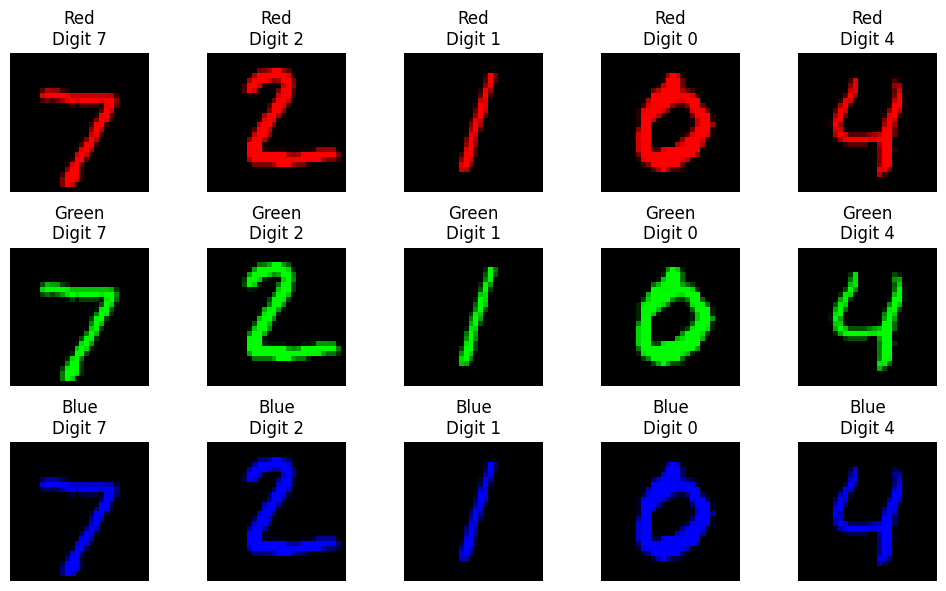

In [ ]:
fig, axes = plt.subplots(
    3,
    5,
    figsize=(10, 6)
)

for row, color_name in enumerate(COLOR_NAMES):

    color_dataset = ColoredMNIST(
        raw_test_dataset,
        fixed_color=color_name
    )

    for column in range(5):

        image, label = color_dataset[column]

        # Reverse normalization
        display_image = (
            image * STD + MEAN
        )

        display_image = display_image.clamp(
            0,
            1
        )

        axes[row, column].imshow(
            display_image.permute(
                1,
                2,
                0
            )
        )

        axes[row, column].set_title(
            f"{color_name}\nDigit {label}"
        )

        axes[row, column].axis("off")

plt.tight_layout()

plt.show()

## c. TESTING ACCURACY ON THE TRANSFORMED DATASET I

## My Testing Accuracy on the Colored MNIST

The baseline CNN trained only on regular MNIST is now evaluated using the Colored MNIST test dataset.

No additional training is performed before this test.

In [ ]:
colored_loss, colored_accuracy = evaluate_model(
    model,
    colored_test_loader
)

print(
    f"My colored MNIST Test Loss: "
    f"{colored_loss:.4f}"
)

print(
    f"My colored MNIST Test Accuracy: "
    f"{colored_accuracy:.2f}%"
)

My colored MNIST Test Loss: 0.6340
My colored MNIST Test Accuracy: 91.65%


# My Transformation 2: Rotated MNIST

## Create Rotated MNIST

The second transformed dataset is created by rotating MNIST digits to different angles.

The rotation angles used in this experiment are:

- −60°
- −40°
- −20°
- +20°
- +40°
- +60°

Using multiple rotation angles allows the effect of rotation angle on classification performance to be investigated.

In [ ]:
ROTATION_ANGLES = [-60,-40, -20, 20, 40, 60]

In [ ]:
class RotatedMNIST(Dataset):

    def __init__(
        self,
        base_dataset,
        fixed_angle=None
    ):

        self.base_dataset = base_dataset

        self.fixed_angle = fixed_angle


    def __len__(self):

        return len(
            self.base_dataset
        )


    def __getitem__(self, index):

        image, label = self.base_dataset[index]

        # Select rotation angle
        if self.fixed_angle is None:

            angle = ROTATION_ANGLES[
                index % len(ROTATION_ANGLES)
            ]

        else:

            angle = self.fixed_angle

        # Rotate image
        rotated_image = TF.rotate(
            image,
            angle=angle,
            interpolation=
            transforms.InterpolationMode.BILINEAR,
            fill=0
        )

        # Convert to tensor
        rotated_image = TF.to_tensor(
            rotated_image
        )

        # Convert from grayscale to 3 channels
        rotated_image = rotated_image.repeat(
            3,
            1,
            1
        )

        # Normalize
        rotated_image = (
            rotated_image - MEAN
        ) / STD

        return rotated_image, label

## Let me create the Rotated MNIST Test DataLoader

Each MNIST test image is assigned one of the selected rotation angles while retaining its original digit label.

In [ ]:
rotated_test_dataset = RotatedMNIST(
    raw_test_dataset
)

rotated_test_loader = DataLoader(
    rotated_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(
    "My number of Rotated MNIST test images:",
    len(rotated_test_dataset)
)

My number of Rotated MNIST test images: 10000


## Let me visualize Different Rotation Angles

The following examples show the same type of MNIST digit at the different rotation angles used in this experiment.

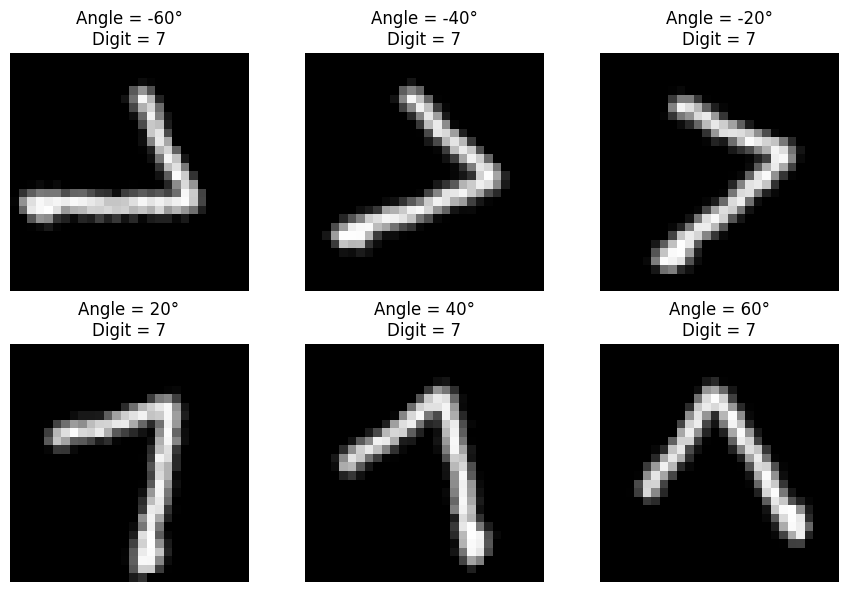

In [ ]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(9, 6)
)

for ax, angle in zip(
    axes.flat,
    ROTATION_ANGLES
):

    angle_dataset = RotatedMNIST(
        raw_test_dataset,
        fixed_angle=angle
    )

    image, label = angle_dataset[0]

    # Reverse normalization
    display_image = (
        image * STD + MEAN
    )

    display_image = display_image.clamp(
        0,
        1
    )

    ax.imshow(
        display_image.permute(
            1,
            2,
            0
        )
    )

    ax.set_title(
        f"Angle = {angle}°\nDigit = {label}"
    )

    ax.axis("off")

plt.tight_layout()

plt.show()

## c. TESTING ACCURACY ON THE TRANSFORMED DATASET (Rotated MNIST)

The baseline CNN trained only on regular MNIST is now evaluated using the Rotated MNIST test dataset.

This experiment measures how sensitive the CNN is to changes in digit orientation.

In [ ]:
rotated_loss, rotated_accuracy = evaluate_model(
    model,
    rotated_test_loader
)

print(
    f"My rotated MNIST Test Loss: "
    f"{rotated_loss:.4f}"
)

print(
    f"My rotated MNIST Test Accuracy: "
    f"{rotated_accuracy:.2f}%"
)

My rotated MNIST Test Loss: 2.0599
My rotated MNIST Test Accuracy: 64.24%


## d. (OPTIONAL) ANALYZING PERFORMANCE ACROSS DIFFERENT SUBGROUPS WITHIN THE TRANSFORMED DATASET (E.G., COLOR-WISE PERFORMANCE AND/OR ROTATION-ANGLE-WISE PERFORMANCE)

## Let's perform Color-Wise Performance Analysis

The model is separately evaluated on red, green and blue MNIST digits.

This analysis helps determine whether CNN performance is affected differently by different digit colors.

In [ ]:
color_results = []

for color_name in COLOR_NAMES:

    color_dataset = ColoredMNIST(
        raw_test_dataset,
        fixed_color=color_name
    )

    color_loader = DataLoader(
        color_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    loss, accuracy = evaluate_model(
        model,
        color_loader
    )

    color_results.append({
        "Color": color_name,
        "Accuracy (%)": accuracy,
        "Loss": loss
    })


color_results_df = pd.DataFrame(
    color_results
)

color_results_df

,Color,Accuracy (%),Loss
0,Red,96.43,0.474807
1,Green,97.21,0.407427
2,Blue,82.15,1.014784


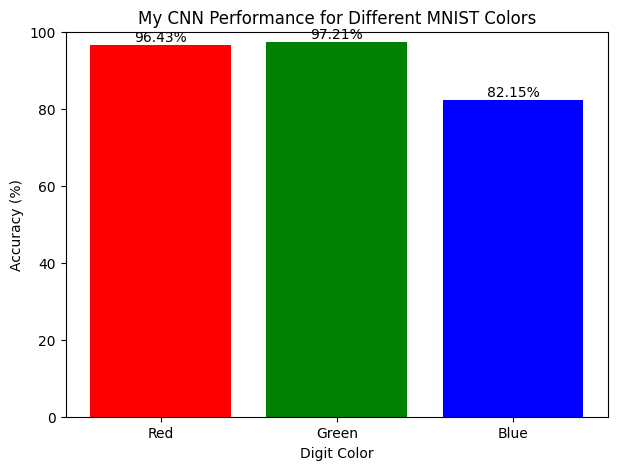

In [ ]:
plt.figure(figsize=(7, 5))

bars = plt.bar(
    color_results_df["Color"],
    color_results_df["Accuracy (%)"],
    color=["red", "green", "blue"]
)

plt.xlabel("Digit Color")
plt.ylabel("Accuracy (%)")
plt.title("My CNN Performance for Different MNIST Colors")
plt.ylim(0, 100)

# I want my display accuracy value matches each bar
for bar, accuracy in zip(
    bars,
    color_results_df["Accuracy (%)"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{accuracy:.2f}%",
        ha="center"
    )

plt.show()

## Now, let's do Rotation-Angle-Wise Performance Analysis

The model is evaluated independently at every rotation angle.

This makes it possible to determine how classification accuracy changes as the magnitude of rotation increases.

In [ ]:
rotation_results = []

for angle in ROTATION_ANGLES:

    angle_dataset = RotatedMNIST(
        raw_test_dataset,
        fixed_angle=angle
    )

    angle_loader = DataLoader(
        angle_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    loss, accuracy = evaluate_model(
        model,
        angle_loader
    )

    rotation_results.append({
        "Rotation Angle (degrees)": angle,
        "Accuracy (%)": accuracy,
        "Loss": loss
    })


rotation_results_df = pd.DataFrame(
    rotation_results
)

rotation_results_df

,Rotation Angle (degrees),Accuracy (%),Loss
0,-60,27.03,4.786319
1,-40,62.28,1.916769
2,-20,94.61,0.174917
3,20,95.72,0.139472
4,40,70.12,1.329233
5,60,33.49,4.129993


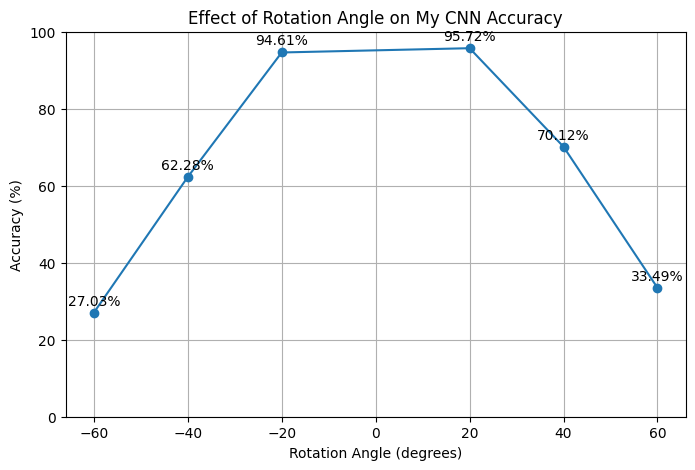

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    rotation_results_df["Rotation Angle (degrees)"],
    rotation_results_df["Accuracy (%)"],
    marker="o"
)

# Add accuracy values to each point
for angle, accuracy in zip(
    rotation_results_df["Rotation Angle (degrees)"],
    rotation_results_df["Accuracy (%)"]
):
    plt.text(
        angle,
        accuracy + 2,
        f"{accuracy:.2f}%",
        ha="center"
    )

plt.xlabel("Rotation Angle (degrees)")
plt.ylabel("Accuracy (%)")

plt.title(
    "Effect of Rotation Angle on My CNN Accuracy"
)

plt.ylim(0, 100)
plt.grid(True)

plt.show()

## My Comparisons on Original and Transformed MNIST Performance

The following table summarizes the performance of the CNN on:

- Original MNIST
- Colored MNIST
- Rotated MNIST

This comparison shows how image transformations affect the generalization ability of a CNN trained only on regular MNIST.

In [ ]:
summary_results = pd.DataFrame({

    "Dataset": [
        "Original MNIST",
        "Colored MNIST",
        "Rotated MNIST"
    ],

    "Accuracy (%)": [
        original_accuracy,
        colored_accuracy,
        rotated_accuracy
    ],

    "Loss": [
        original_loss,
        colored_loss,
        rotated_loss
    ]
})

summary_results

,Dataset,Accuracy (%),Loss
0,Original MNIST,99.18,0.024381
1,Colored MNIST,91.65,0.634022
2,Rotated MNIST,64.24,2.059907


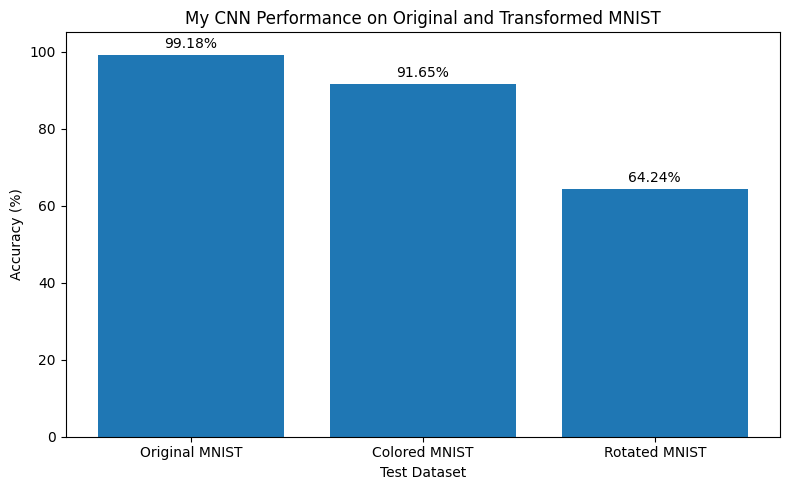

In [ ]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    summary_results["Dataset"],
    summary_results["Accuracy (%)"]
)

plt.ylabel("Accuracy (%)")
plt.xlabel("Test Dataset")

plt.title(
    "My CNN Performance on Original and Transformed MNIST"
)

plt.ylim(0, 105)

# Add accuracy value above each bar
for bar, accuracy in zip(
    bars,
    summary_results["Accuracy (%)"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{accuracy:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

## Results and Discussion

The CNN was trained for five epochs using only the regular MNIST training dataset. The training loss decreased consistently from **0.1713** in the first epoch to **0.0235** in the fifth epoch, which means that the model successfully learned the digit classification task.

On the original MNIST test dataset, the model achieved an accuracy of **99.18%** with a test loss of **0.0244**. This high accuracy provides a strong baseline for evaluating the effect of the two image transformations.

When I evaluated on Colored MNIST, the accuracy decreased to **91.65%**, with a test loss of **0.6340**. This represents a reduction of **7.53 percentage points** compared with the original MNIST accuracy. The color-wise analysis showed accuracies of **96.43% for red**, **97.21% for green**, and **82.15% for blue**. Green produced the highest classification accuracy, while blue produced the lowest, which shows that the baseline CNN was affected differently by the three color transformations.

The effect of rotation was substantially greater. The overall accuracy on Rotated MNIST decreased to **64.24%**, with a test loss of **2.0599**. This is a reduction of **34.94 percentage points** compared with the original MNIST accuracy.

The rotation-angle-wise analysis further demonstrated the effect of digit orientation. At **−20°** and **+20°**, the model maintained relatively high accuracies of **94.61%** and **95.72%**, respectively. At **−40°** and **+40°**, accuracy decreased to **62.28%** and **70.12%**. The largest rotations produced the poorest results with accuracies of only **27.03% at −60°** and **33.49% at +60°**.

So I would say the results show that the CNN generalizes well to the original MNIST test data but is less robust to image transformations that were not present during baseline training. Rotation produced a considerably larger reduction in classification performance than coloring and the rotation-angle analysis shows that performance generally deteriorated as the magnitude of rotation increased.

## My Observations from the experiment

The main observations are:

1. **Successful CNN training:** The training loss decreased from **0.1713 to 0.0235** over five epochs.

2. **Strong baseline performance:** The CNN achieved **99.18% accuracy** on the original MNIST test dataset.

3. **Effect of color transformation:** Accuracy decreased to **91.65%** on Colored MNIST. Among the three colors, green achieved the highest accuracy (**97.21%**), followed by red (**96.43%**), while blue produced the lowest accuracy (**82.15%**).

4. **Effect of rotation transformation:** Accuracy decreased substantially to **64.24%** on Rotated MNIST, showing that rotation had a greater effect on the baseline CNN than coloring.

5. **Effect of rotation angle:** Small rotations of ±20° retained relatively high classification accuracy, whereas larger rotations caused substantial performance degradation. The lowest accuracy was **27.03% at −60°**.

These observations demonstrate that a CNN trained only on regular MNIST can achieve excellent performance on similarly distributed test images but may experience substantial performance degradation when the appearance or orientation of the input images changes.

# e. (OPTIONAL) IMPROVING THE MODEL ON THE TRANSFORMED DATASETS.
# This is an optional Extension: Improving Robustness to Transformations

The baseline model was deliberately trained only on regular MNIST in accordance with the assignment instructions.

As an additional experiment, a second CNN can be trained using rotation and color augmentation.

The purpose is to investigate whether exposing the network to transformed images during training improves its ability to classify transformed MNIST test images.

In [ ]:
class AugmentedMNIST(Dataset):

    def __init__(self, base_dataset):

        self.base_dataset = base_dataset


    def __len__(self):

        return len(
            self.base_dataset
        )


    def __getitem__(self, index):

        image, label = self.base_dataset[index]

        # Random rotation
        angle = random.uniform(
            -60,
            60
        )

        image = TF.rotate(
            image,
            angle=angle,
            interpolation=
            transforms.InterpolationMode.BILINEAR,
            fill=0
        )

        grayscale_image = TF.to_tensor(
            image
        )

        # Random color choice
        choice = random.choice([
            "Gray",
            "Red",
            "Green",
            "Blue"
        ])

        if choice == "Gray":

            transformed_image = (
                grayscale_image.repeat(
                    3,
                    1,
                    1
                )
            )

        else:

            transformed_image = (
                grayscale_image
                *
                COLOR_VECTORS[choice]
            )

        transformed_image = (
            transformed_image - MEAN
        ) / STD

        return transformed_image, label

In [ ]:
raw_train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True
)

augmented_train_dataset = AugmentedMNIST(
    raw_train_dataset
)

augmented_train_loader = DataLoader(
    augmented_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

In [ ]:
improved_model = SimpleCNN().to(
    device
)

improved_optimizer = torch.optim.Adam(
    improved_model.parameters(),
    lr=0.001
)

IMPROVED_EPOCHS = 5

improved_training_losses = []

In [ ]:
for epoch in range(IMPROVED_EPOCHS):

    improved_model.train()

    running_loss = 0.0

    total_samples = 0

    for images, labels in augmented_train_loader:

        images = images.to(device)

        labels = labels.to(device)

        improved_optimizer.zero_grad()

        outputs = improved_model(
            images
        )

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        improved_optimizer.step()

        batch_size = labels.size(0)

        running_loss += (
            loss.item() * batch_size
        )

        total_samples += batch_size

    average_loss = (
        running_loss
        /
        total_samples
    )

    improved_training_losses.append(
        average_loss
    )

    print(
        f"Epoch {epoch + 1}/"
        f"{IMPROVED_EPOCHS}, "
        f"Training Loss: "
        f"{average_loss:.4f}"
    )

Epoch 1/5, Training Loss: 0.4508
Epoch 2/5, Training Loss: 0.1694
Epoch 3/5, Training Loss: 0.1294
Epoch 4/5, Training Loss: 0.1104
Epoch 5/5, Training Loss: 0.0946


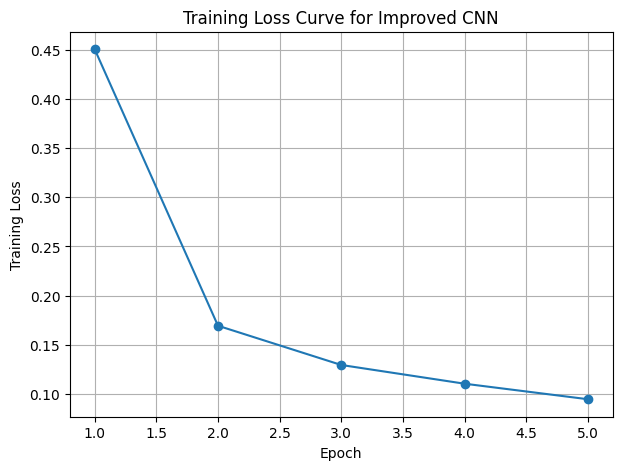

In [ ]:
plt.figure(figsize=(7, 5))

plt.plot(
    range(
        1,
        IMPROVED_EPOCHS + 1
    ),
    improved_training_losses,
    marker="o"
)

plt.xlabel("Epoch")

plt.ylabel("Training Loss")

plt.title(
    "Training Loss Curve for Improved CNN"
)

plt.grid(True)

plt.show()

# Evaluating the improved model

In [ ]:
improved_original_loss, improved_original_accuracy = evaluate_model(
    improved_model,
    test_loader
)

improved_colored_loss, improved_colored_accuracy = evaluate_model(
    improved_model,
    colored_test_loader
)

improved_rotated_loss, improved_rotated_accuracy = evaluate_model(
    improved_model,
    rotated_test_loader
)

In [ ]:
comparison_results = pd.DataFrame({

    "Dataset": [
        "Original MNIST",
        "Colored MNIST",
        "Rotated MNIST"
    ],

    "Baseline Accuracy (%)": [
        original_accuracy,
        colored_accuracy,
        rotated_accuracy
    ],

    "Improved Accuracy (%)": [
        improved_original_accuracy,
        improved_colored_accuracy,
        improved_rotated_accuracy
    ]
})

comparison_results

,Dataset,Baseline Accuracy (%),Improved Accuracy (%)
0,Original MNIST,99.18,97.94
1,Colored MNIST,91.65,97.80
2,Rotated MNIST,64.24,97.25


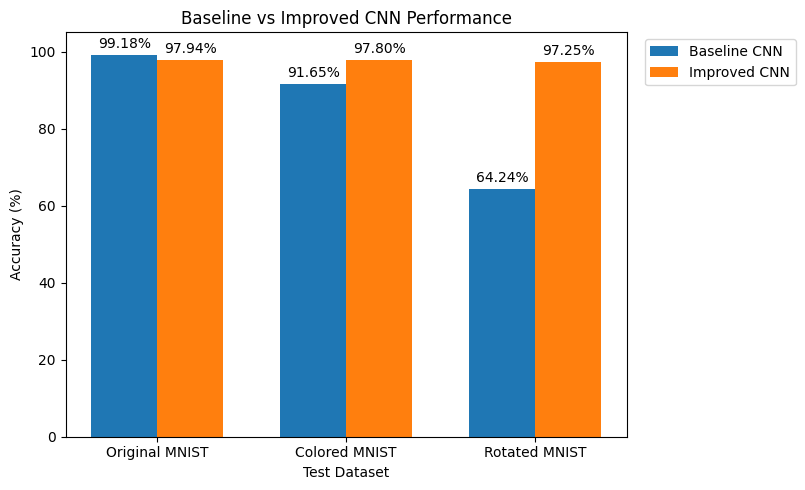

In [ ]:
import numpy as np

dataset_names = comparison_results["Dataset"]

baseline_values = comparison_results["Baseline Accuracy (%)"]
improved_values = comparison_results["Improved Accuracy (%)"]

x = np.arange(len(dataset_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))

bars1 = ax.bar(
    x - width / 2,
    baseline_values,
    width,
    label="Baseline CNN"
)

bars2 = ax.bar(
    x + width / 2,
    improved_values,
    width,
    label="Improved CNN"
)

ax.set_xlabel("Test Dataset")
ax.set_ylabel("Accuracy (%)")

ax.set_title(
    "Baseline vs Improved CNN Performance"
)

ax.set_xticks(x)
ax.set_xticklabels(dataset_names)

ax.set_ylim(0, 105)

# I better put legend outside the graph
ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0)
)

# Let me add accuracy values on each bar
for bars in [bars1, bars2]:
    for bar in bars:

        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 1,
            f"{height:.2f}%",
            ha="center",
            va="bottom"
        )

plt.tight_layout(rect=[0, 0, 0.82, 1])

plt.show()

## My Conclusion
### In addtional to my previous results' discussions and observations, I would like to put the conclusion in this manner after the improving the model  due to the optional requirements added:

This experiment investigated the performance of a simple CNN trained on regular MNIST and evaluated on both original and transformed MNIST datasets. Two transformations were considered: coloring the MNIST digits using red, green and blue, and also rotating the digits to different angles.

The baseline CNN achieved **99.18% accuracy** on the original MNIST test dataset. But, I could see its performance decreased to **91.65%** on Colored MNIST and **64.24%** on Rotated MNIST. This shows that the CNN was more sensitive to rotation than to color transformation.

The color-wise analysis showed that the baseline model achieved **96.43%**, **97.21%**, and **82.15%** accuracy on red, green, and blue digits, respectively. The rotation-angle-wise analysis showed that relatively small rotations of ±20° maintained high accuracy, while larger rotations caused substantial performance degradation. At −60° and +60°, accuracy decreased to **27.03%** and **33.49%**, respectively.

As an optional improvement, a second CNN was trained using color and rotation augmentation. The improved model achieved **97.94%** accuracy on original MNIST, **97.80%** on Colored MNIST, and **97.25%** on Rotated MNIST. Compared with the baseline model, this represents improvements of **6.15 percentage points** on Colored MNIST and **33.01 percentage points** on Rotated MNIST. However, accuracy on original MNIST decreased slightly by **1.24 percentage points**.

I would say is that the results demonstrate that a CNN trained only on regular MNIST can be sensitive to image transformations, particularly large rotations. Training with appropriate data augmentation substantially improved robustness to both color and rotation transformations, although this was accompanied by a small reduction in performance on the original test distribution.